In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
file_path = '../../data/Data3.csv'  # Make sure the file is in the same directory as the code
data = pd.read_csv(file_path)

# Create a 'Site' column with the first 7 letters of the 'ERBS' column
data['Site'] = data['ERBS'].str[:7]

# Group by 'Site' and 'STARTTIME_DATE', then average the values
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_33360\3089796775.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [4]:
# Function to fit ARIMA model and predict
def fit_arima_model(train):
    model = ARIMA(train, order=(5, 1, 0))  # You can experiment with different ARIMA orders
    fitted_model = model.fit()
    return fitted_model

In [5]:
# Function to create sequences for ARIMA (train-test split)
def create_train_test_split(data, seq_length):
    train_size = int(len(data) * 0.8)
    return data[:train_size], data[train_size:]

# Function for ARIMA prediction and plotting
def arima_prediction_and_plot(target_column):
    results = {}
    degradation_count = 0
    increase_count = 0
    site_predictions = {}

    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        train, test = create_train_test_split(site_data, seq_length)
        
        # Fit ARIMA model
        model = fit_arima_model(train)
        predictions = model.forecast(steps=len(test))
        
        # MSE Calculation
        test_mse = mean_squared_error(test, predictions)
        
        results[site] = test_mse
        site_predictions[site] = (test, predictions)
        
        # Degradation and increase check
        degradation = ((test - predictions) / test) >= 0.5
        increase = ((predictions - test) / test) >= 0.001
        degradation_count += np.sum(degradation)
        increase_count += np.sum(increase)
    
    return results, site_predictions, degradation_count, increase_count

In [6]:
# Plot actual vs predicted for ARIMA
def plot_actual_vs_predicted(site, y_true, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [7]:
# Run the prediction for 'AVG_USR_THRPUT_DL'
avg_usr_thrput_dl_results, site_predictions, degradation_count, increase_count = arima_prediction_and_plot('AVG_USR_THRPUT_DL')


Skipping site BMBNC54 due to insufficient data.


C:\Users\HP\AppData\Local\Temp\ipykernel_33360\1967708773.py:34: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\1967708773.py:35: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\1967708773.py:34: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\1967708773.py:35: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001


In [8]:
# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(avg_usr_thrput_dl_results.items(), key=lambda x: x[1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

Best 5 Sites based on MSE: [('CGANW78', 0.08616283514936658), ('BMBNC11', 0.1674478789777451), ('BMBNC01', 0.1675009152182576), ('BMBNC31', 0.21191265819494295), ('BMKSB25', 0.21255840474790086)]
Worst 5 Sites based on MSE: [('CXUKH72', 82.22649269070367), ('BMKSB55', 94.15480847611543), ('CXUKH53', 97.01270698188632), ('BMKSB57', 97.74153408039118), ('CXUKH27', 136.22374501245883)]


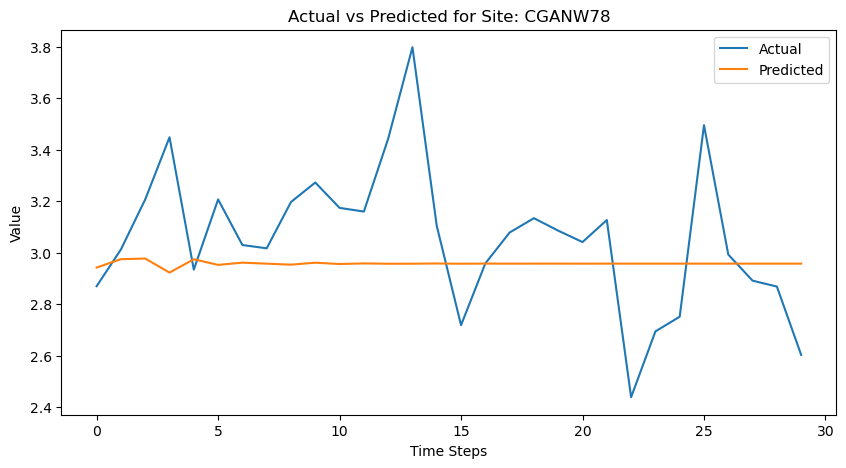

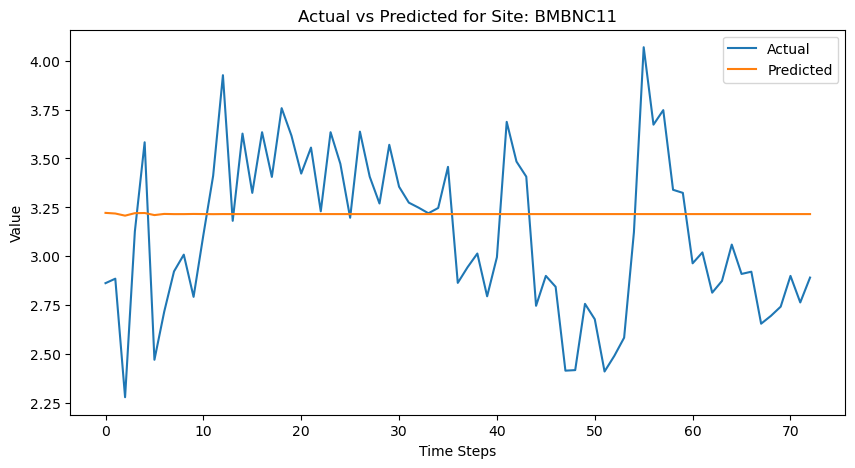

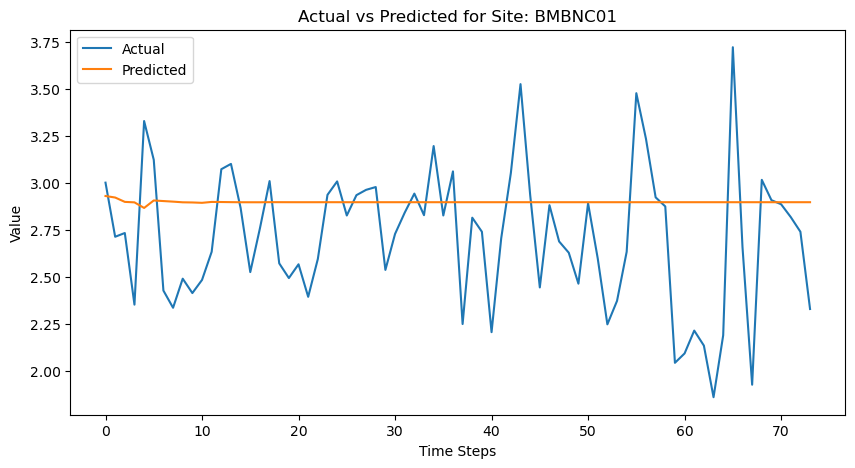

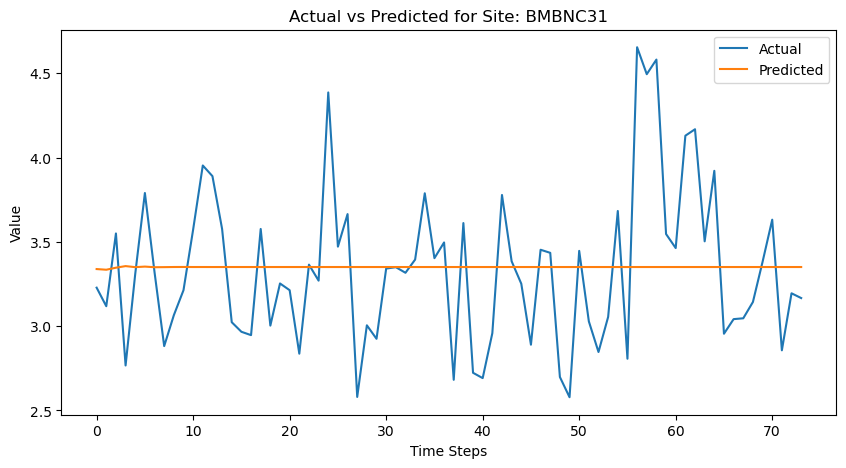

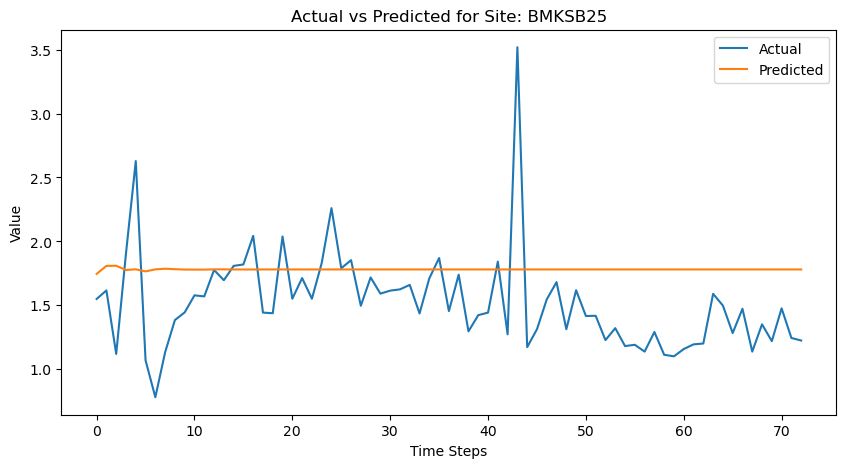

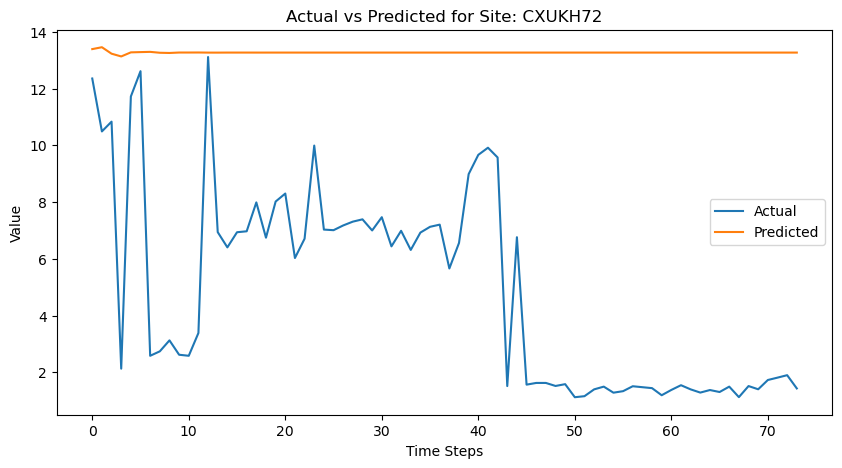

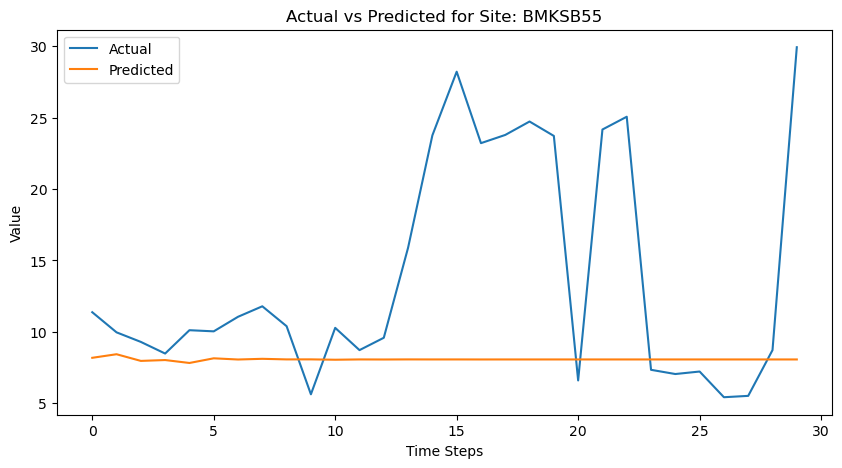

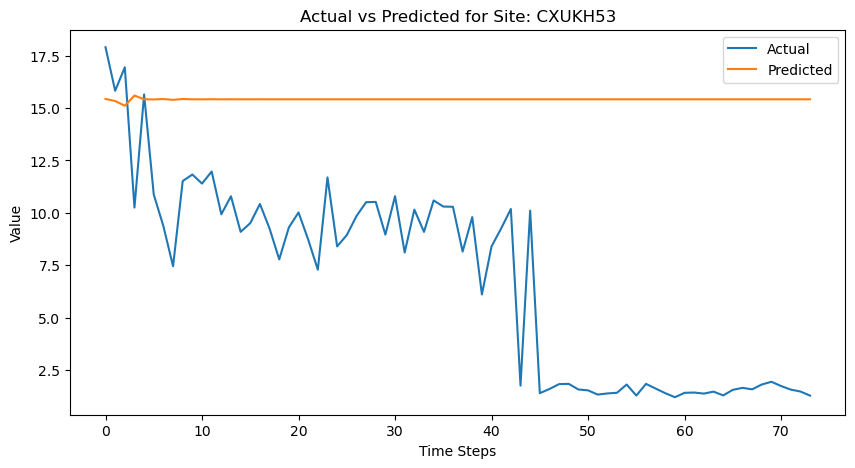

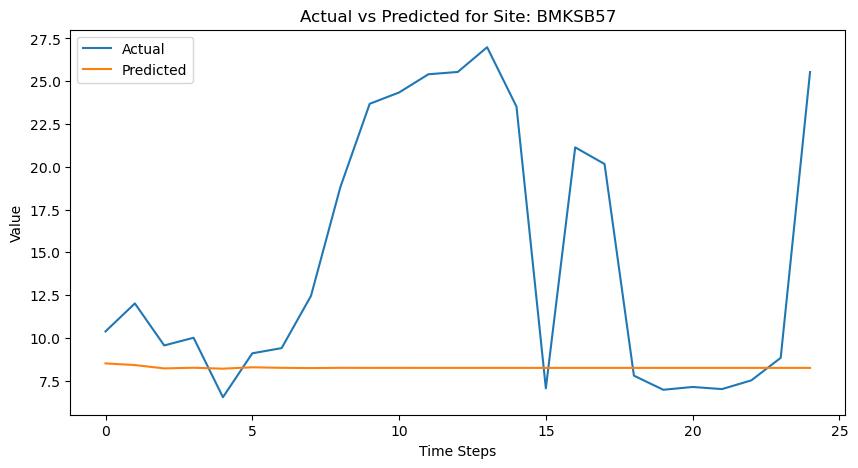

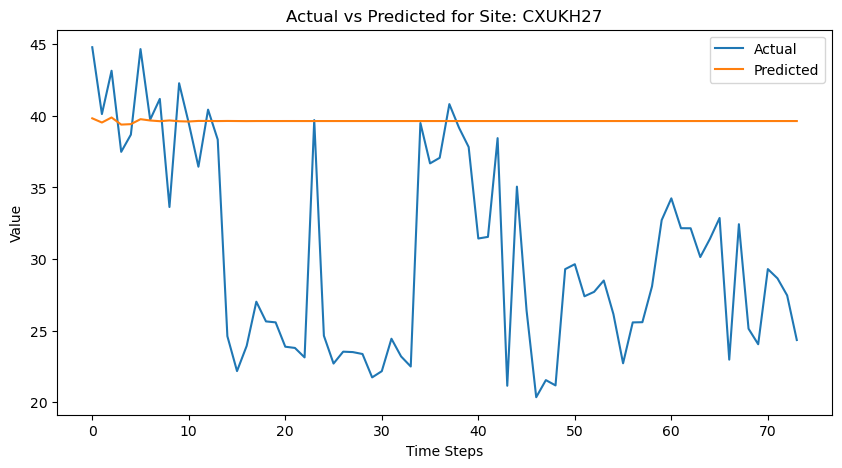

In [9]:
# Plot for the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    y_true, y_pred = site_predictions[site]
    plot_actual_vs_predicted(site, y_true, y_pred)

In [10]:
# Function to fit ARIMA model and predict
def fit_arima_model(train):
    model = ARIMA(train, order=(5, 1, 0))  # You can experiment with different ARIMA orders
    fitted_model = model.fit()
    return fitted_model

# Function to create sequences for ARIMA (train-test split)
def create_train_test_split(data, seq_length):
    train_size = int(len(data) * 0.8)
    return data[:train_size], data[train_size:]

# Function for ARIMA prediction and plotting
def arima_prediction_and_plot(target_column):
    results = {}
    degradation_count = 0
    increase_count = 0
    site_predictions = {}

    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        train, test = create_train_test_split(site_data, seq_length)
        
        # Fit ARIMA model
        model = fit_arima_model(train)
        predictions = model.forecast(steps=len(test))
        
        # MSE Calculation
        test_mse = mean_squared_error(test, predictions)
        
        results[site] = test_mse
        site_predictions[site] = (test, predictions)
        
        # Degradation and increase check
        degradation = ((test - predictions) / test) >= 0.5
        increase = ((predictions - test) / test) >= 0.001
        degradation_count += np.sum(degradation)
        increase_count += np.sum(increase)
    
    return results, site_predictions, degradation_count, increase_count

# Plot actual vs predicted for ARIMA
def plot_actual_vs_predicted(site, y_true, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('AVG_NO_USER')
    plt.legend()
    plt.show()

# Run the prediction for 'AVG_NO_USER'
avg_no_user_results, site_predictions, degradation_count, increase_count = arima_prediction_and_plot('AVG_NO_USER')

# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(avg_no_user_results.items(), key=lambda x: x[1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

Skipping site BMBNC54 due to insufficient data.


C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2273540005.py:40: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2273540005.py:41: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2273540005.py:40: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2273540005.py:41: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001


Best 5 Sites based on MSE: [('BMBNC53', 0.3116809693692976), ('BMBNC48', 0.3190975422165916), ('BMBNC49', 0.5313104586662905), ('BMBNC55', 1.2112818417657412), ('BMBNC56', 3.711025404319641)]
Worst 5 Sites based on MSE: [('CXUKH63', 2760.4852482290858), ('CXUKH39', 2951.132066365637), ('CXUKH06', 3911.2055908570874), ('CXUKH04', 4640.809726353067), ('CXUKH64', 5520.649200072005)]


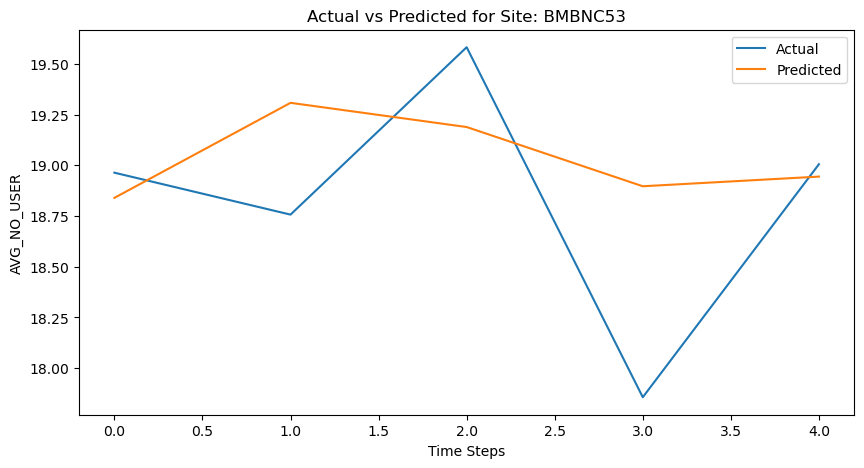

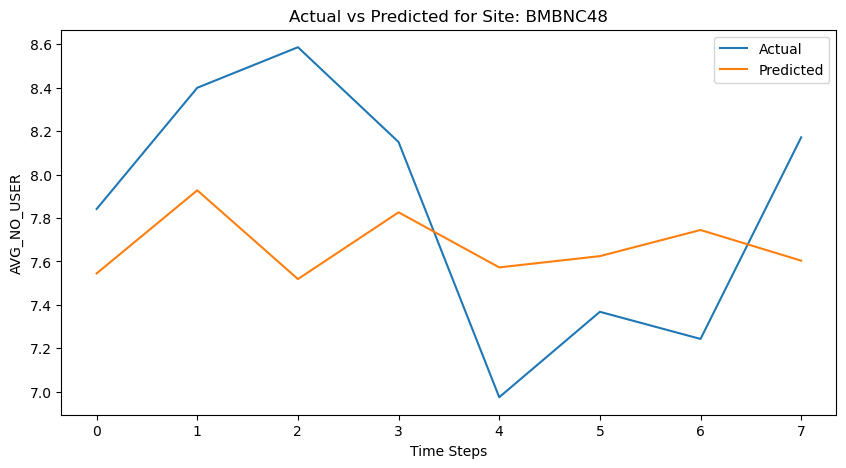

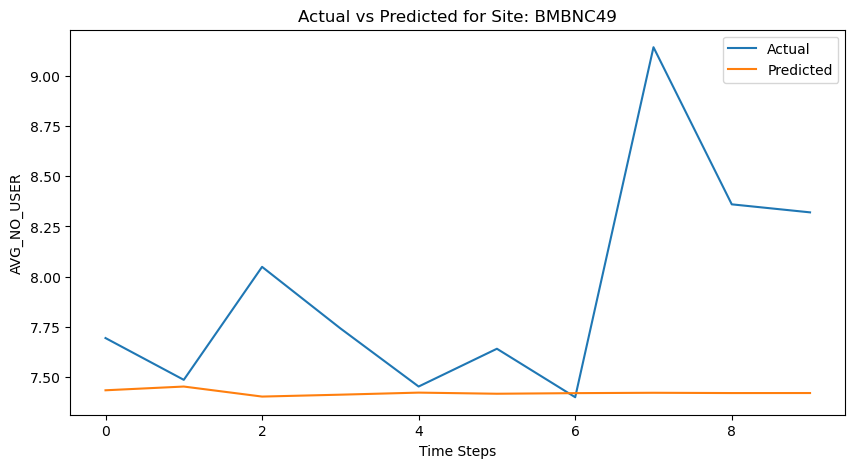

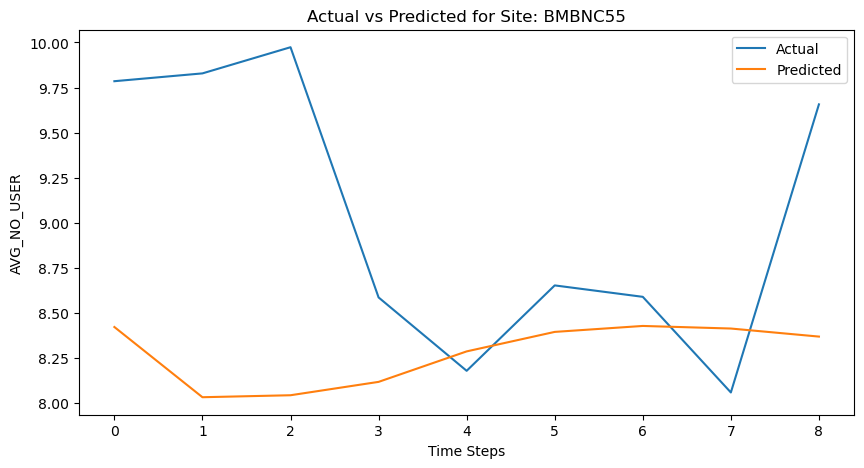

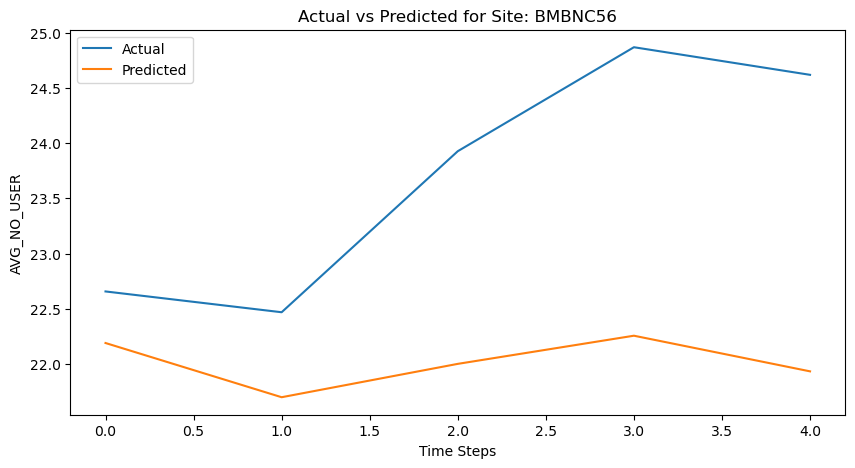

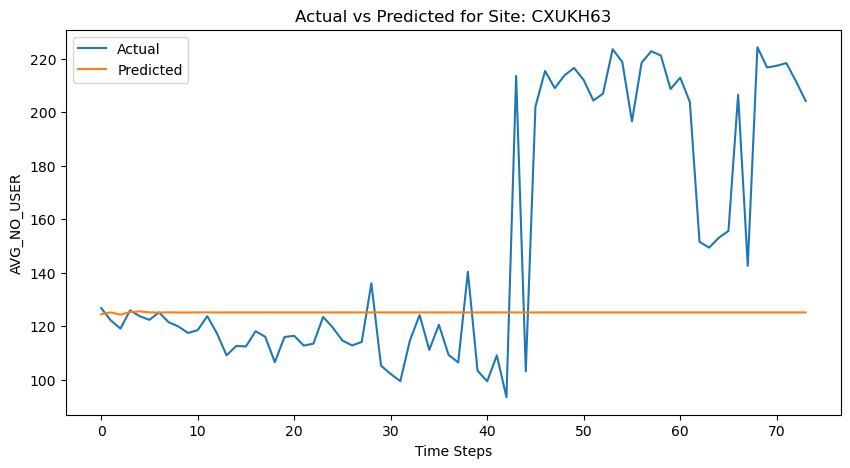

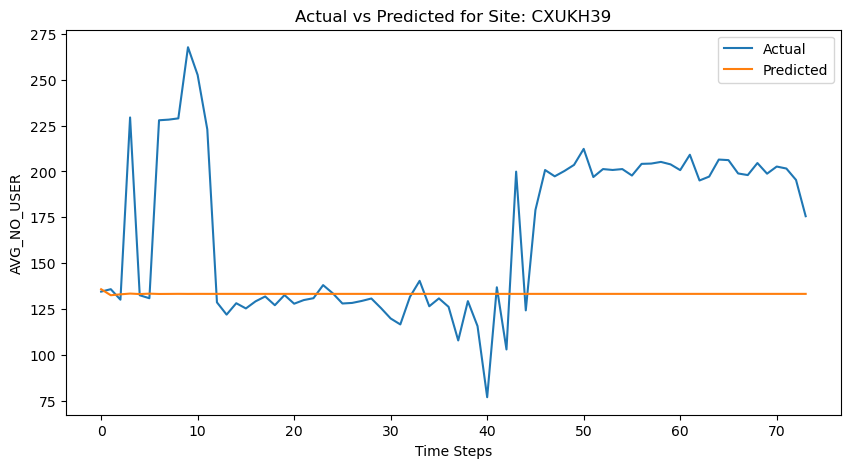

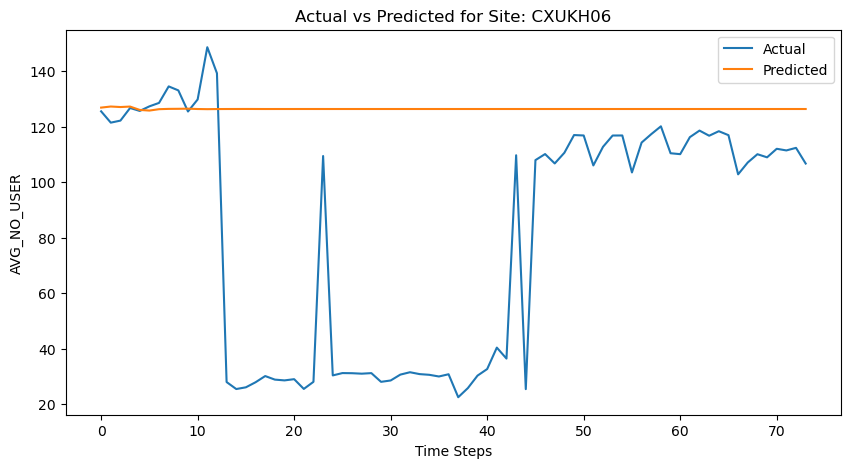

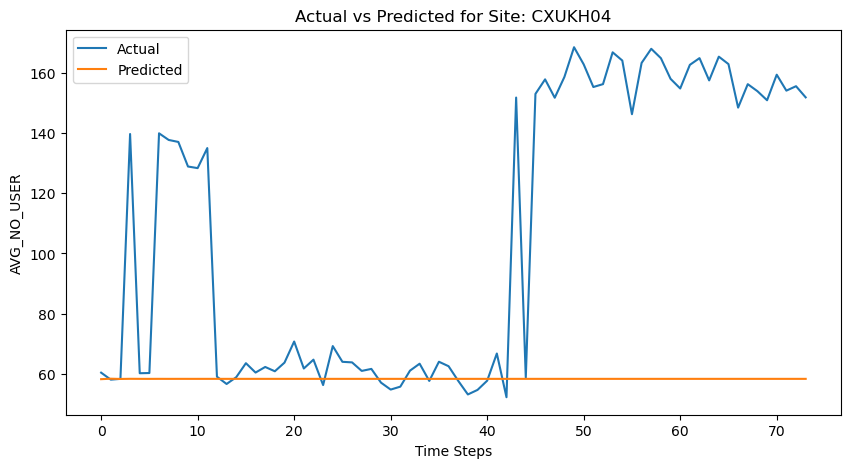

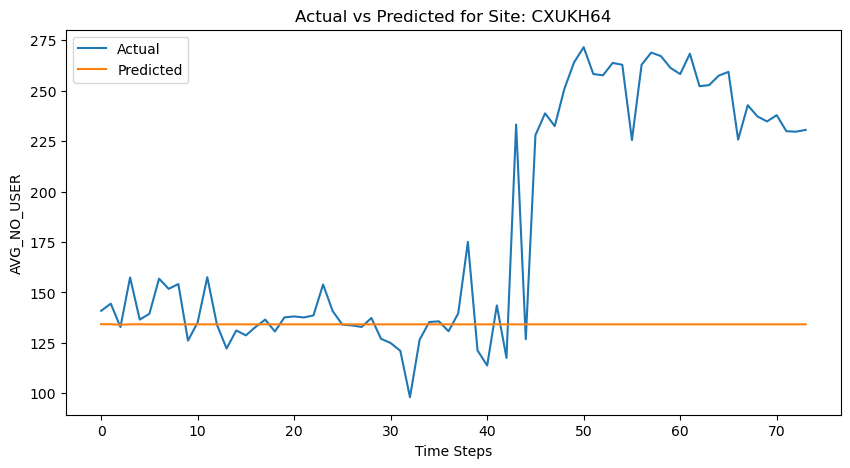

In [11]:
# Plot for the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    y_true, y_pred = site_predictions[site]
    plot_actual_vs_predicted(site, y_true, y_pred)

In [12]:
# Function to fit ARIMA model and predict
def fit_arima_model(train):
    model = ARIMA(train, order=(5, 1, 0))  # You can experiment with different ARIMA orders
    fitted_model = model.fit()
    return fitted_model

# Function to create sequences for ARIMA (train-test split)
def create_train_test_split(data, seq_length):
    train_size = int(len(data) * 0.8)
    return data[:train_size], data[train_size:]

# Function for ARIMA prediction and plotting
def arima_prediction_and_plot(target_column):
    results = {}
    degradation_count = 0
    increase_count = 0
    site_predictions = {}

    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        train, test = create_train_test_split(site_data, seq_length)
        
        # Fit ARIMA model
        model = fit_arima_model(train)
        predictions = model.forecast(steps=len(test))
        
        # MSE Calculation
        test_mse = mean_squared_error(test, predictions)
        
        results[site] = test_mse
        site_predictions[site] = (test, predictions)
        
        # Degradation and increase check
        degradation = ((test - predictions) / test) >= 0.5
        increase = ((predictions - test) / test) >= 0.001
        degradation_count += np.sum(degradation)
        increase_count += np.sum(increase)
    
    return results, site_predictions, degradation_count, increase_count

# Plot actual vs predicted for ARIMA
def plot_actual_vs_predicted(site, y_true, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Run the prediction for 'DL_TRAFFIC_MB'
dl_traffic_mb_results, site_predictions, degradation_count, increase_count = arima_prediction_and_plot('DL_TRAFFIC_MB')

# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(dl_traffic_mb_results.items(), key=lambda x: x[1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Skipping site BMBNC54 due to insufficient data.


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2306277389.py:40: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2306277389.py:41: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001
C:\Users\HP\AppData\Local\Temp\ipykernel_33360\2306277389.py:40: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_333

Best 5 Sites based on MSE: [('BMBNC49', 5162760.120684131), ('BMBNC48', 11440081.374282785), ('BMBNC56', 11982902.871617632), ('BMBNC55', 16698814.252010843), ('CGANW20', 36734202.7488454)]
Worst 5 Sites based on MSE: [('CXUKH32', 4665944680.202673), ('CXUKH04', 5126466338.861592), ('CXUKH21', 5194334917.174515), ('CXUKH02', 5568549718.599012), ('CXUKH16', 5898506519.397765)]


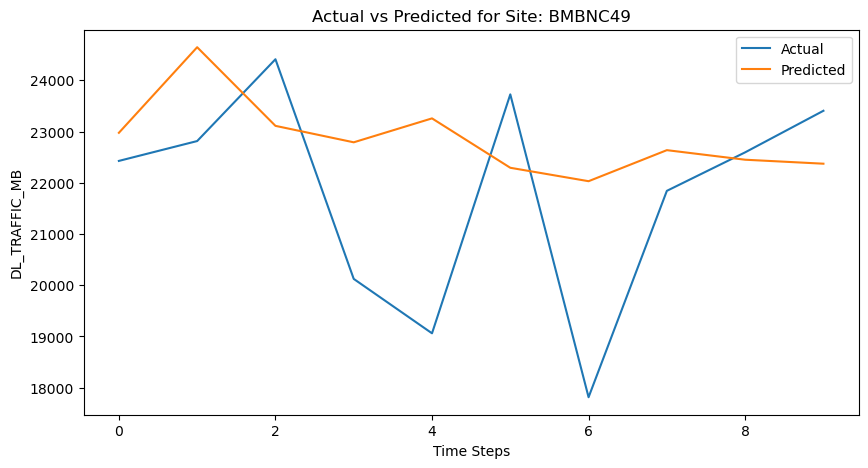

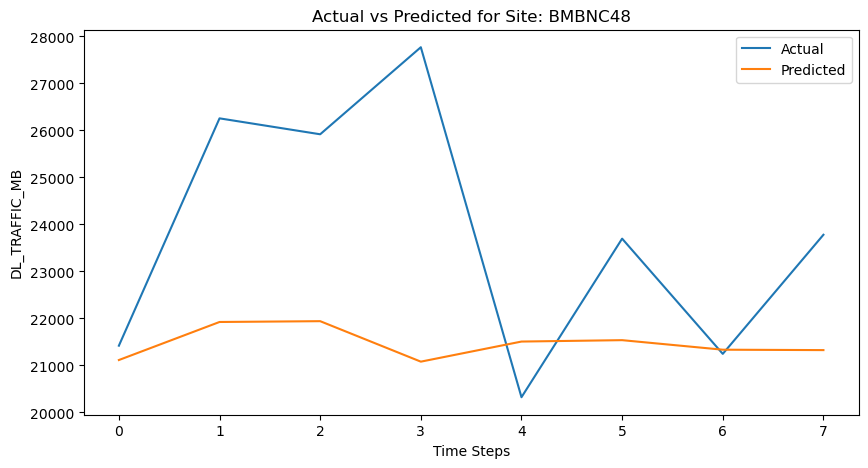

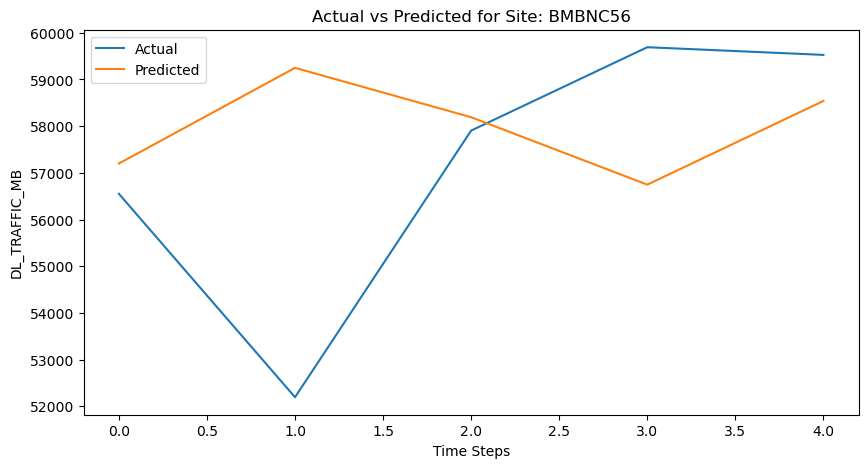

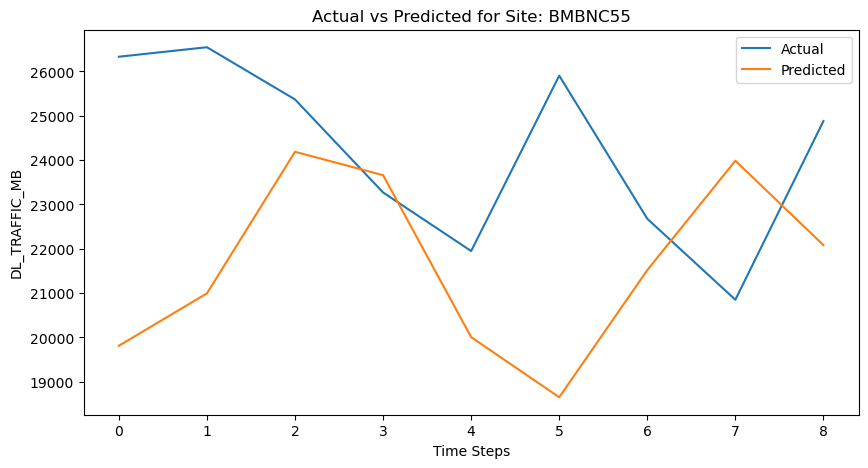

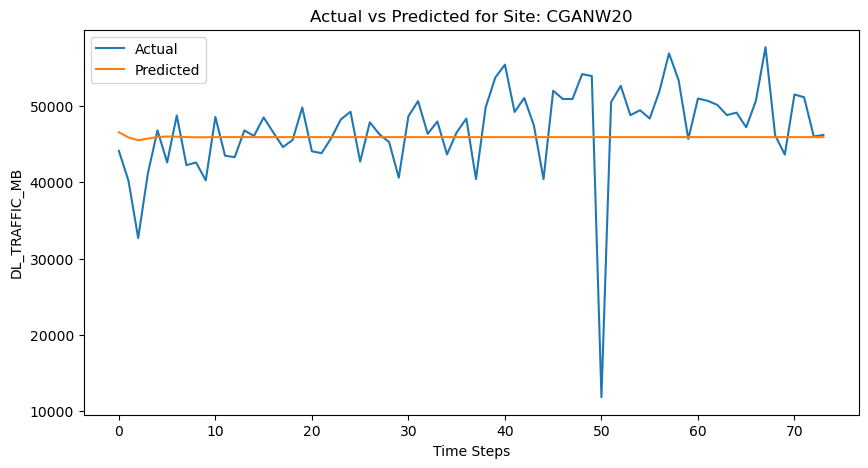

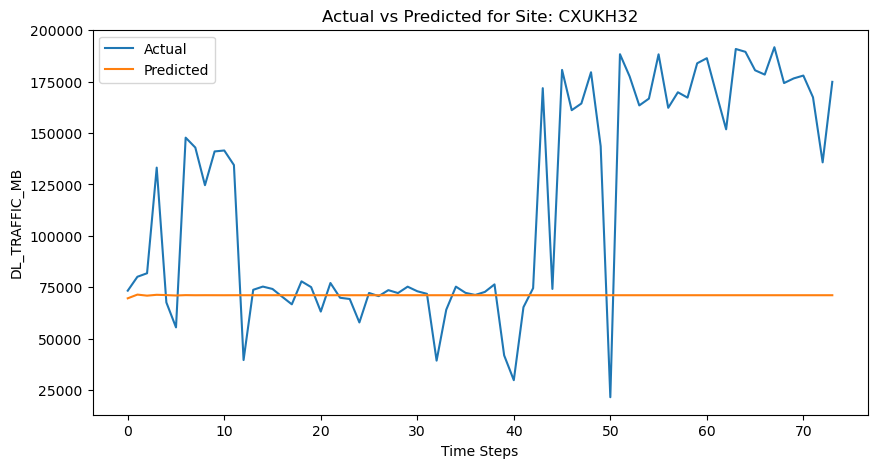

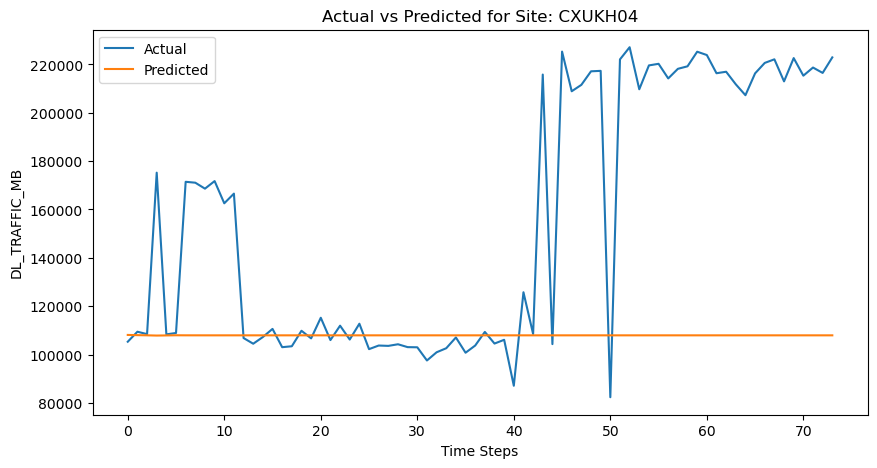

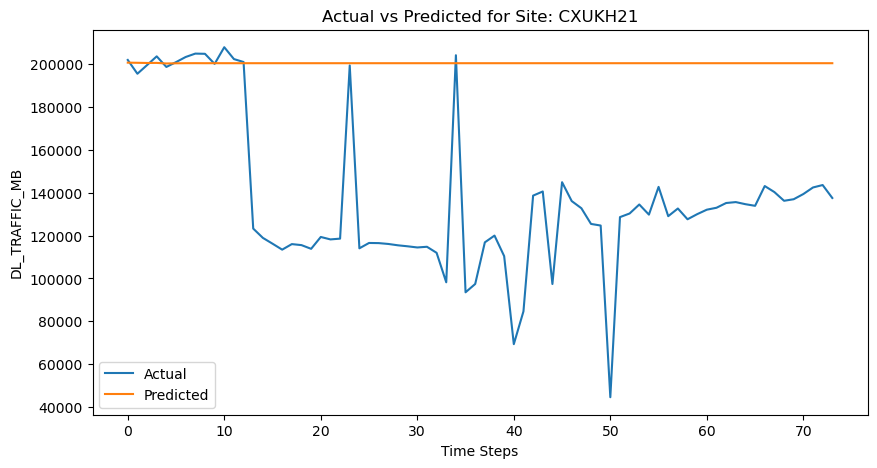

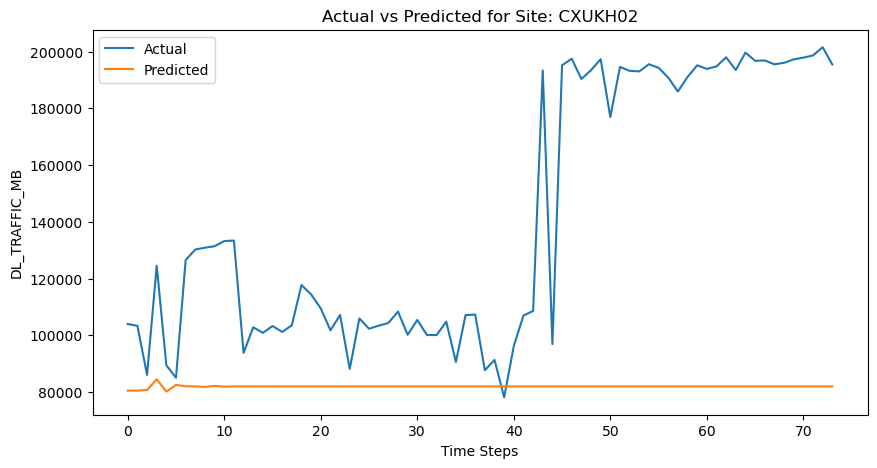

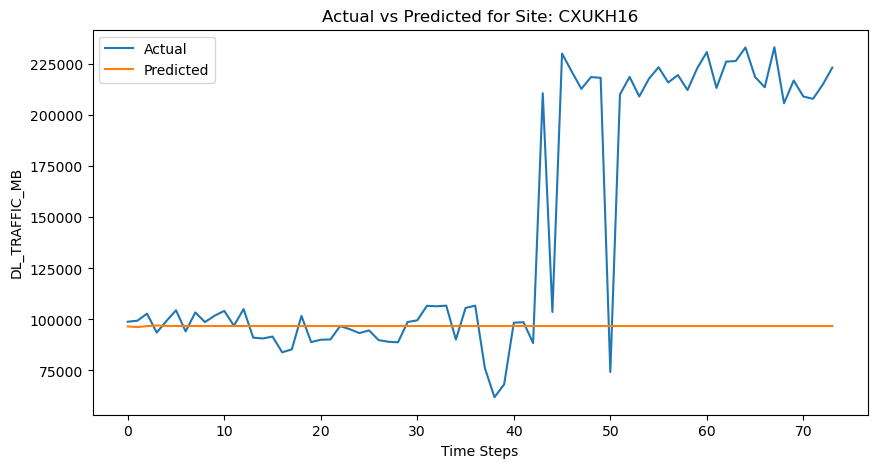

In [13]:
# Plot for the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    y_true, y_pred = site_predictions[site]
    plot_actual_vs_predicted(site, y_true, y_pred)